# XGBoost — Difficult Airway Prediction
Baseline model for comparison with TabTransformer.

In [23]:
import warnings, numpy as np, pandas as pd, xgboost as xgb, time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
warnings.filterwarnings("ignore")
ROOT = Path.cwd()

In [24]:
# Load dataset
df = pd.read_excel(ROOT / "D:\Minor_Project\dataset.xlsx")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} cols")
print(f"Target distribution:\n{df['Target'].value_counts().sort_index()}")

Dataset: 2500 rows, 31 cols
Target distribution:
Target
0    833
1    834
2    833
Name: count, dtype: int64


In [25]:
# Preprocessing
CAT_COLS = ["Gender","Previous_Airway_Records","Disease_Arthritis","Disease_Diabetes","Disease_Down_Syndrome",
    "Breathing_Snoring","Breathing_Sleep_Apnea","Symptom_Voice_Changes","Symptom_Difficulty_Swallowing",
    "Symptom_Cant_Lie_Flat","Injury_Swelling","Injury_Previous_Neck_Fracture","Previous_Emergencies_ICU",
    "BMI_Category","Beard","Chest_Size","Neck_Structure","Mallampati_Score","TMD_Category",
    "Jaw_Movement","Neck_Movement_Category","Tissue_Flexibility"]
NUM_COLS = ["Age","BMI","Neck_Circumference_cm","Mouth_Opening_mm","Thyromental_Distance_TMD_cm",
    "Sternomental_Distance_SMD_cm","Neck_Movement_Degrees"]
TARGET = "Target"

X = df.drop(columns=["Patient_ID", TARGET])
y = df[TARGET].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

Train: 1750, Val: 375, Test: 375


In [26]:
# Train XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {"objective":"multi:softprob","num_class":3,"max_depth":6,"learning_rate":0.1,
          "subsample":0.8,"colsample_bytree":0.8,"eval_metric":"mlogloss","seed":42,"device":"cuda"}

start = time.time()
evals_result = {}
model = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dtrain,"train"),(dval,"val")],
                  evals_result=evals_result, early_stopping_rounds=20, verbose_eval=50)
elapsed = time.time() - start
print(f"\nTraining time: {elapsed:.2f}s")
print(f"Best iteration: {model.best_iteration}")

# Extract train and validation losses
train_losses = evals_result.get("train", {}).get("mlogloss", [])
val_losses = evals_result.get("val", {}).get("mlogloss", [])

model.save_model(str(ROOT / "D:/Minor_Project/checkpoints/xgboost_best.json"))
print("Model saved to checkpoints/xgboost_best.json")

[0]	train-mlogloss:1.00334	val-mlogloss:1.01333
[50]	train-mlogloss:0.15904	val-mlogloss:0.38832
[100]	train-mlogloss:0.06787	val-mlogloss:0.37869
[127]	train-mlogloss:0.04871	val-mlogloss:0.38326

Training time: 1.28s
Best iteration: 107
Model saved to checkpoints/xgboost_best.json


In [27]:
# Evaluate
y_probs = model.predict(dtest)
y_preds = np.argmax(y_probs, axis=1)
cm = confusion_matrix(y_test, y_preds)

print(classification_report(y_test, y_preds, target_names=["Easy","Moderate","Difficult"], digits=3))
print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {(y_preds==y_test).mean():.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_probs, multi_class='ovr'):.4f}")

              precision    recall  f1-score   support

        Easy      0.862     0.848     0.855       125
    Moderate      0.760     0.784     0.772       125
   Difficult      0.919     0.904     0.911       125

    accuracy                          0.845       375
   macro avg      0.847     0.845     0.846       375
weighted avg      0.847     0.845     0.846       375

Confusion Matrix:
[[106  19   0]
 [ 17  98  10]
 [  0  12 113]]

Accuracy: 0.8453
AUC-ROC:  0.9624


In [28]:
# Feature Importance
importance = model.get_score(importance_type="gain")
sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print("Top 10 features (gain):")
for name, score in sorted_imp[:10]:
    print(f"  {name}: {score:.1f}")

Top 10 features (gain):
  Mallampati_Score: 11.6
  TMD_Category: 2.8
  BMI_Category: 2.7
  Thyromental_Distance_TMD_cm: 1.8
  Neck_Movement_Category: 1.7
  Disease_Down_Syndrome: 1.4
  BMI: 1.3
  Breathing_Sleep_Apnea: 1.2
  Neck_Circumference_cm: 1.0
  Neck_Movement_Degrees: 0.9


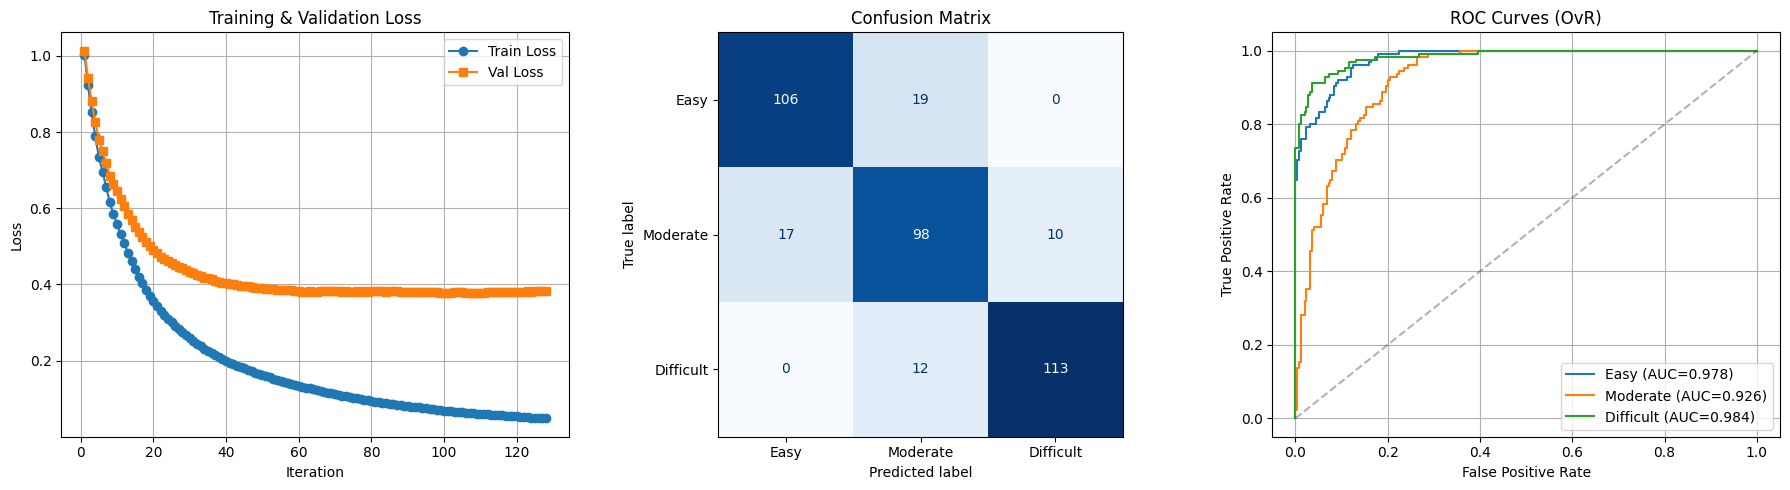

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

# Check if train_losses and val_losses exist
if 'train_losses' not in globals() or 'val_losses' not in globals():
    print("train_losses and/or val_losses are not defined. Please re-run the training cell before plotting.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss", marker="o")
    ax.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss", marker="s")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Training & Validation Loss")
    ax.legend()
    ax.grid(True)

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_preds,
        display_labels=["Easy", "Moderate", "Difficult"],
        cmap="Blues", ax=axes[1], colorbar=False,
    )
    axes[1].set_title("Confusion Matrix")

    ax = axes[2]
    classes = ["Easy", "Moderate", "Difficult"]
    for i in range(3):
        y_bin = (y_test == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves (OvR)")
    ax.legend(loc="lower right")
    ax.grid(True)

    plt.tight_layout()
    plt.show()